In [44]:
import numpy as np
help(np.loadtxt)
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Help on function loadtxt in module numpy:

loadtxt(fname, dtype=<class 'float'>, comments='#', delimiter=None, converters=None, skiprows=0, usecols=None, unpack=False, ndmin=0, encoding='bytes', max_rows=None)
    Load data from a text file.
    
    Each row in the text file must have the same number of values.
    
    Parameters
    ----------
    fname : file, str, or pathlib.Path
        File, filename, or generator to read.  If the filename extension is
        ``.gz`` or ``.bz2``, the file is first decompressed. Note that
        generators should return byte strings.
    dtype : data-type, optional
        Data-type of the resulting array; default: float.  If this is a
        structured data-type, the resulting array will be 1-dimensional, and
        each row will be interpreted as an element of the array.  In this
        case, the number of columns used must match the number of fields in
        the data-type.
    comments : str or sequence of str, optional
        The char

In [60]:
np.loadtxt('baData(56).csv', skiprows= 1, unpack = 'True')

ValueError: could not convert string to float: '1000,'

In [61]:
pd.read_csv('baData(56).csv')

,Frequency [Hz],Amplitude [dB],Phase [deg]
0,1000.000000,-45.936569,88.898727
1,1183.673469,-45.786663,89.022385
2,1367.346939,-45.504772,88.470024
3,1551.020408,-45.271591,89.357368
4,1734.693878,-45.029716,88.774048
5,1918.367347,-44.676220,88.638397
6,2102.040816,-44.283928,88.599724
7,2285.714286,-43.894691,88.803444
8,2469.387755,-43.428959,87.858948
9,2653.061224,-42.756042,87.275848


In [65]:
freq, amp, phase = pd.read_csv('baData(56).csv')
pd.read_csv('baData(56).csv')
amp

' Amplitude [dB]'

In [68]:
freq = pd.read_csv('baData(56).csv')['Frequency [Hz]']
amp = pd.read_csv('baData(56).csv')[' Amplitude [dB]']

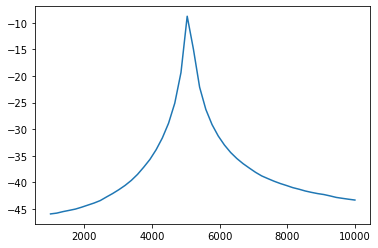

In [81]:
plt.plot(freq, amp)

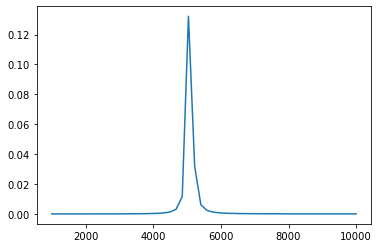

In [111]:
def model(w, w0, Rp, Q):
    R = 47*10**3
    return abs(Rp/R+Rp)/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))
    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()
amp_np=10**(amp_np/10)
plt.plot(freq_np, amp_np)

p0 = (5000,(47*10**3/(1-0.12)),0.001)
popt, pcov = curve_fit(model, freq_np, amp_np)

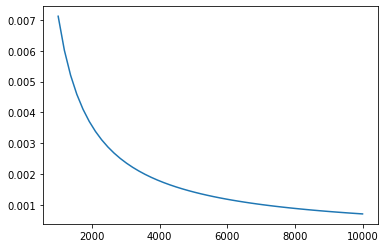

In [113]:
plt.plot(freq_np, model(freq_np, *popt))

<ipython-input-94-286ca1e69e46>:3: RuntimeWarning: invalid value encountered in sqrt
  return (Rp/R+Rp)/np.sqrt((1-Q**2*(w/w0 - w0/w)**2))


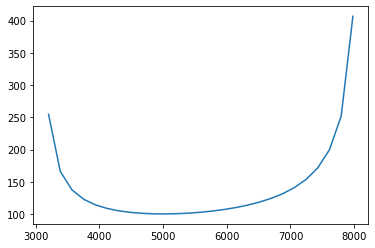

In [96]:
plt.plot(freq, model(freq_np, 5000, 100,1))